# 01 — Your First ECRH Ray Trace

This notebook walks through the minimal steps to simulate Electron Cyclotron Resonance Heating (ECRH) in a fusion plasma with Raytrax — **no external data files required**.

We build a synthetic circular-cross-section tokamak from scratch, define parabolic plasma profiles, launch a beam, and inspect the result.

**You will learn how to:**
- Enable JAX 64-bit precision (required by Raytrax)
- Construct a `MagneticConfiguration` from a hand-crafted cylindrical grid
- Define `RadialProfiles` and a `Beam`
- Call `raytrax.trace` and read the `TraceResult`
- Visualise the beam trajectory on an R–Z cross-section

## 1 · JAX setup

JAX defaults to 32-bit arithmetic. Raytrax requires 64-bit — enable it **before** any JAX or Raytrax import.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from raytrax import Beam, MagneticConfiguration, RadialProfiles, trace
from raytrax.plot.plot2d import plot_beamtrace_rz, plot_effective_radius_rz

## 2 · Synthetic tokamak equilibrium

We construct a simple circular tokamak analytically:

| Parameter | Value |
|-----------|-------|
| Major radius $R_0$ | 3 m |
| Minor radius $a$ | 1 m |
| On-axis field $B_0$ | 2.5 T |
| Frequency | 140 GHz (2nd harmonic O-mode) |

The toroidal field is $B_\varphi = B_0 R_0 / R$ and the normalised effective radius is $\rho = \sqrt{(R-R_0)^2 + Z^2}/a$.

In [2]:
R0, a, B0 = 3.0, 1.0, 2.5  # major radius [m], minor radius [m], on-axis field [T]
n_R, n_Z = 60, 70

R_grid = jnp.linspace(R0 - 1.5 * a, R0 + 1.5 * a, n_R)
Z_grid = jnp.linspace(-1.5 * a, 1.5 * a, n_Z)
R_2d, Z_2d = jnp.meshgrid(R_grid, Z_grid, indexing="ij")

# Pure toroidal field and circular flux surfaces
B_phi = B0 * R0 / R_2d
rho_2d = jnp.sqrt((R_2d - R0) ** 2 + Z_2d**2) / a

phi_grid = jnp.array([0.0])  # single toroidal plane (axisymmetric)
rphiz = jnp.stack(jnp.meshgrid(R_grid, phi_grid, Z_grid, indexing="ij"), axis=-1)

mag_field_grid = jnp.stack(
    [jnp.zeros_like(R_2d), B_phi, jnp.zeros_like(R_2d)], axis=-1
)[:, jnp.newaxis, :, :]

rho_grid = rho_2d[:, jnp.newaxis, :]

rho_1d = jnp.linspace(0, 1, 200)
dvolume_drho = 4.0 * jnp.pi**2 * R0 * a**2 * rho_1d  # dV/dρ for a torus

mag_conf = MagneticConfiguration(
    rphiz=rphiz,
    magnetic_field=mag_field_grid,
    rho=rho_grid,
    nfp=1,
    is_stellarator_symmetric=False,
    rho_1d=rho_1d,
    dvolume_drho=dvolume_drho,
    is_axisymmetric=True,
)
print("MagneticConfiguration ready:", mag_conf.rphiz.shape)

MagneticConfiguration ready: (60, 1, 70, 3)


## 3 · Plasma profiles

Parabolic electron density $n_e(\rho) = n_0 (1-\rho^2)$ and temperature $T_e(\rho) = T_0 (1-\rho^2)$.
Units: $n_e$ in $10^{20}$ m$^{-3}$, $T_e$ in keV.

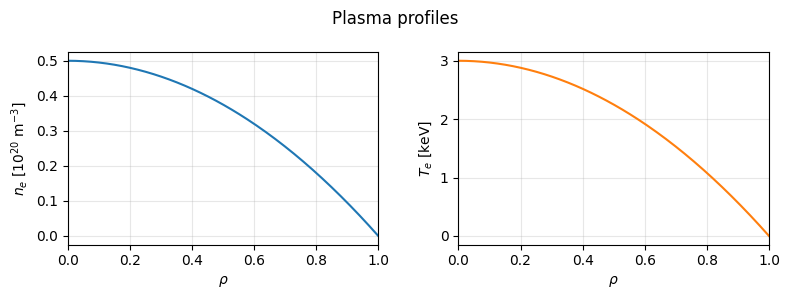

In [3]:
rho_prof = jnp.linspace(0, 1, 200)

profiles = RadialProfiles(
    rho=rho_prof,
    electron_density=0.5 * (1.0 - rho_prof**2),  # 0.5e20 m⁻³ on axis
    electron_temperature=3.0 * (1.0 - rho_prof**2),  # 3 keV on axis
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.plot(np.array(rho_prof), np.array(profiles.electron_density))
ax1.set_xlabel(r"$\rho$")
ax1.set_ylabel(r"$n_e$ [$10^{20}$ m$^{-3}$]")
ax1.set_xlim(0, 1)
ax1.grid(alpha=0.3)
ax2.plot(np.array(rho_prof), np.array(profiles.electron_temperature), color="C1")
ax2.set_xlabel(r"$\rho$")
ax2.set_ylabel(r"$T_e$ [keV]")
ax2.set_xlim(0, 1)
ax2.grid(alpha=0.3)
fig.suptitle("Plasma profiles")
plt.tight_layout()
plt.show()

## 4 · Beam definition

We launch an O-mode beam at 140 GHz from outside the plasma ($R > R_0 + a$), pointing inward.

In [4]:
beam = Beam(
    position=jnp.array([R0 + 1.5 * a, 0.0, 0.0]),  # outer midplane, just outside LCFS
    direction=jnp.array([-1.0, 0.0, 0.0]),  # pointing straight inward (−R̂)
    frequency=140e9,  # Hz  (2nd-harmonic O-mode for B0 = 2.5 T)
    mode="O",
    power=1e6,  # 1 MW
)
print(beam)

Beam(position=Array([4.5, 0. , 0. ], dtype=float64), direction=Array([-1.,  0.,  0.], dtype=float64), frequency=140000000000.0, mode='O', power=1000000.0)


## 5 · Run the ray tracer

The first call triggers JIT compilation — subsequent calls (e.g. inside an optimisation loop) are fast.

In [5]:
result = trace(mag_conf, profiles, beam)

print(f"Optical depth τ          = {result.optical_depth:.4f}")
print(f"Absorbed power fraction  = {result.absorbed_power_fraction:.1%}")
print(f"Absorbed power           = {result.absorbed_power / 1e3:.1f} kW")
print(
    f"Deposition ρ             = {result.deposition_rho_mean:.3f} ± {result.deposition_rho_std:.3f}"
)

Optical depth τ          = 0.4660
Absorbed power fraction  = 37.3%
Absorbed power           = 372.5 kW
Deposition ρ             = 0.075 ± 0.030


## 6 · Visualise the beam trajectory

Plot the beam path on an R–Z cross-section, colour-coded by linear power density (MW/m), overlaid with flux-surface contours.

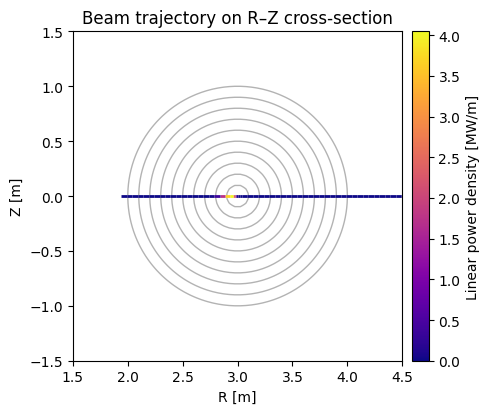

In [6]:
fig, ax = plt.subplots(figsize=(5, 5))

# Flux-surface contours
plot_effective_radius_rz(mag_conf, phi=0.0, ax=ax)
# Beam trajectory coloured by absorbed power density
plot_beamtrace_rz(result.beam_profile, phi=0.0, ax=ax, lw=2)

ax.set_title("Beam trajectory on R–Z cross-section")
plt.tight_layout()
plt.show()

## 7 · Power deposition profile

The radial power deposition density $dP/d\rho$ tells you where inside the plasma the energy is deposited.

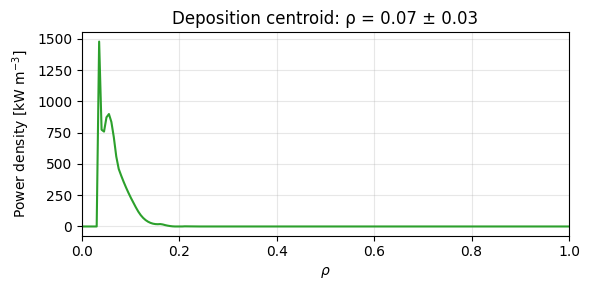

In [7]:
rho_dep = np.array(result.radial_profile.rho)
power_dep = np.array(result.radial_profile.volumetric_power_density)  # W/m³

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(rho_dep, power_dep / 1e3, color="C2")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"Power density [kW m$^{-3}$]")
ax.set_xlim(0, 1)
ax.set_title(
    f"Deposition centroid: ρ = {result.deposition_rho_mean:.2f} ± {result.deposition_rho_std:.2f}"
)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()